# **🛩️ ATAS**

The ATAS (Airial Threat Assesment System) is an end-to-end machine learning engineering project that combines

- computer vision,
- structured machine learning,
- tactical scenario generation,
- and interactive visualization into a single pipeline.

**The project is divided into three major components:**

- Aircraft Classification Model
- ETA Regressor Model
- Hit Classification Model

---

**In this notebook**

# **🎯 Hit Probability Classifier**

This notebook focuses on building the Hit Probability Classifier using `scikit-learn` and `ensemble methods` to predict whether a missile will hit your aircraft after an evasion attempt, across `1,000,000` synthetic engagement scenarios.

## **1. Problem Definition**

Physics can tell you where a missile is going, that is simple trajectory calculation.

What it cannot tell you is **whether the missile will still hit you after you maneuver.**

Given the engagement conditions including aircraft states, missile specifications, 
geometry, and countermeasure state, predict **whether the missile hits your aircraft 
after an evasion attempt** → a binary outcome of **hit or miss**.

This outcome depends on non-linear interactions between aspect angle, maneuverability, 
missile phase, and countermeasure effectiveness, making it a genuine ML problem, 
not something physics equations can resolve.

---

## **2. Data**

The data used here is synthetic, generated using real physics equations since 
real labeled engagement data does not exist publicly. This is standard practice; 
companies like Tesla and Waymo also train models on synthetic data.

**How the data was made:**
- Generated by `physics_generator.py` using real aircraft specs from `aircraft_metadata.csv`
- Stored as `synthetic_engagements.csv`

**Key notes on Data**
- The data contains 16 columns, 1,000,000 rows
- **14 columns are input features:**
  
| Feature | Description |
|---|---|
| `launch_distance` | Distance from which the missile was fired (metres) |
| `remaining_distance` | Current distance of missile from your aircraft |
| `closure_rate` | Combined closing speed of missile + your aircraft (m/s) |
| `azimuth` | Horizontal angle of incoming threat (0°–360°) |
| `elevation` | Vertical angle of incoming threat (-90°–+90°) |
| `missile_phase` | 0 = boost, 1 = mid-course, 2 = terminal |
| `your_speed` | Your current airspeed (m/s) |
| `your_altitude` | Your current altitude (metres) |
| `your_maneuverability` | 0 = low, 1 = medium, 2 = high |
| `enemy_altitude` | Enemy aircraft altitude (metres) |
| `missile_speed` | Speed of incoming missile (m/s) |
| `missile_range` | Max effective range of missile (metres) |
| `enemy_generation` | Aircraft generation (3.5, 4, 4.5, 5) |
| `countermeasure_deployed` | 0 = not deployed, 1 = deployed |
  
- **2 columns are target labels:**
  
| Label | Description |
|---|---|
| `evasion_time` | Minimum time available to evade the missile (seconds) - dropped here |
| `hit` | Whether the missile hits after evasion (0 = miss, 1 = hit) - **target for this model** |

---

## **3. Evaluation**

The primary evaluation metric for this model is **Recall** - it tells us how 
often the model correctly identifies missiles that will actually hit, which is 
directly meaningful in a tactical context.

Missing a real hit (false negative) is far more dangerous than a false alarm 
(false positive). The model should never tell a pilot they are safe when they 
are not.

**All three metrics will be tracked:**

| Metric | Goal |
|---|---|
| Recall | > 0.90 — minimise missed hits |
| F1 Score | > 0.85 — balance between precision and recall |
| ROC-AUC | > 0.95 — overall discrimination ability |

---

> Note: Recall is prioritised over precision here. In a tactical system, a 
false alarm costs a countermeasure. A missed hit costs a life.

> These targets are preliminary. Final metric selection and thresholds will be 
confirmed after EDA once the class balance of the `hit` column is known. 
If the dataset is heavily imbalanced, additional metrics may be introduced.

---

## **4. Features**

Some information about the data:

* We are dealing with structured tabular data so we will be using ensemble methods (Random Forest, XGBoost).
* The dataset contains `1,000,000` synthetic engagement scenarios across `101` aircraft types.
* All 14 input features are numerical - no text, no images, no missing values.
* Features span four groups:
   * **Engagement geometry:** `launch_distance`, `remaining_distance`, `closure_rate`, `azimuth`, `elevation`, `missile_phase`
   * **Your aircraft state:** `your_speed`, `your_altitude`, `your_maneuverability`
   * **Enemy aircraft state:** `enemy_altitude`
   * **Threat specs:** `missile_speed`, `missile_range`, `enemy_generation`, `countermeasure_deployed`
* The target variable is `hit` (binary, 0 = miss, 1 = hit) → the `evasion_time` column is dropped.
* Data was generated from physics rules — class balance of the `hit` column will be confirmed during EDA.
  
* Features like `aspect_angle`, `your_maneuverability`, and `countermeasure_deployed` introduce non-linear interactions that make this a genuine ML problem rather than a simple trajectory calculation.

---

## **5. Preparing the Tools**

We will be using the following libraries for this project:

* **NumPy** → numerical operations
* **Pandas** → loading and manipulating the synthetic engagement dataset
* **Matplotlib** → visualizing feature distributions and model performance
* **Scikit-learn** → model training, evaluation metrics, and train/test split
* **XGBoost** → gradient boosted trees (primary candidate)
* **Joblib** → saving and loading trained models

In [1]:
# Importing the Librabries
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import xgboost
import joblib

%matplotlib inline

In [2]:
# Use for naming the files
import datetime, pytz
ist = pytz.timezone("Asia/Kolkata")
datetime.datetime.now(ist).strftime('%Y-%m-%d_%H-%M-%S')

'2026-06-05_16-04-56'

In [3]:
import os
from pathlib import Path

# Set to:
# - "auto"   -> detect the runtime
# - "colab"  -> force Google Colab
# - "kaggle" -> force Kaggle
# - "local"  -> force local machine
# - "lightning" -> force Lightning AI (workspace)

FORCE_ENV = "auto"

def detect_env():
    if os.path.exists("/teamspace/studios"):
        return "lightning"
    if os.path.exists("/kaggle"):
        return "kaggle"
    if "COLAB_GPU" in os.environ or os.path.exists("/content/drive"):
        return "colab"
    return "local"

def find_local_project_root(start: Path) -> Path:
    """Find project root by walking up to a folder that contains environment.yml."""
    for candidate in [start, *start.parents]:
        if (candidate / "environment.yml").exists():
            return candidate
    return start

ENV = detect_env() if FORCE_ENV == "auto" else FORCE_ENV

if ENV == "colab":
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/ATAS_Project")
    DATA_ROOT = PROJECT_ROOT / "data"
elif ENV == "kaggle":
    PROJECT_ROOT = Path("/kaggle/working")
    DATA_ROOT = Path("/kaggle/input/datasets/eakempreetsingh/atas-aircraft-dataset")
    if not DATA_ROOT.exists():
        DATA_ROOT = PROJECT_ROOT / "data"
elif ENV == "lightning":
    PROJECT_ROOT = Path("/teamspace/studios/this_studio")
    DATA_ROOT = PROJECT_ROOT / "data"
else:
    PROJECT_ROOT = find_local_project_root(Path.cwd().resolve())
    DATA_ROOT = PROJECT_ROOT / "data"

# Standard paths
LOG_DIR = PROJECT_ROOT / "logs"
MODEL_DIR = PROJECT_ROOT / "models"
RELEASE_MODELS_DIR = PROJECT_ROOT / "release_models"
PREDICTIONS_DIR = PROJECT_ROOT / "predictions"

# ETA-specific path
HIT_DATA_ROOT = DATA_ROOT / "hit"

# Create folders safely (never inside read-only Kaggle input)
for folder_path in [PROJECT_ROOT, DATA_ROOT, LOG_DIR, MODEL_DIR, RELEASE_MODELS_DIR, PREDICTIONS_DIR, HIT_DATA_ROOT]:
    if ENV == "kaggle" and str(folder_path).startswith("/kaggle/input"):
        continue
    try:
        os.makedirs(folder_path, exist_ok=True)
    except PermissionError:
        pass

print(f"ENV:                {ENV}")
print(f"PROJECT_ROOT:       {PROJECT_ROOT}")
print(f"DATA_ROOT:          {DATA_ROOT}")
print(f"HIT_DATA_ROOT:      {HIT_DATA_ROOT}")
print(f"RELEASE_MODELS_DIR: {RELEASE_MODELS_DIR}")

ENV:                local
PROJECT_ROOT:       /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project
DATA_ROOT:          /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data
HIT_DATA_ROOT:      /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data/hit
RELEASE_MODELS_DIR: /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/release_models


## **6. Importing the data and preparing it for modelling**

In [4]:
# Confirm resolved project paths (do not overwrite them here)
PROJECT_ROOT, DATA_ROOT, HIT_DATA_ROOT

(PosixPath('/mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project'),
 PosixPath('/mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data'),
 PosixPath('/mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data/hit'))

In [5]:
# Loading the dataframe from environment-aware data root
aircraft_df = pd.read_csv(DATA_ROOT / "synthetic_engagements.csv",
                          low_memory=False)

# # Drop the evasion_time column for Hit Classifier
# aircraft_df = aircraft_df.drop(columns="evasion_time")
# aircraft_df.head()

# Will drop after dropping rows who has eta more than 300sec 

In [6]:
# Drop physically unrealistic scenarios (same filter applied in ETA regressor)
aircraft_df = aircraft_df[aircraft_df["evasion_time"] <= 300].reset_index(drop=True)

# Now drop evasion_time - not needed for hit classifier
aircraft_df = aircraft_df.drop(columns="evasion_time")

print(aircraft_df.shape)
aircraft_df.head()

(999405, 15)


,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,hit
0,33895.443880,5709.789560,795.851952,110.969042,26.933223,2,191.657942,20767.395530,2,15722.748320,857,35000,4.0,1,0
1,9775.992373,1963.280302,846.016340,91.346829,-24.938668,2,515.353333,24375.588350,2,10976.820090,857,35000,4.0,0,0
2,24382.997910,7464.370311,829.119185,127.394632,47.364627,2,67.779862,21557.988950,0,6022.335489,857,35000,4.0,1,0
3,28058.181280,17335.851080,868.412502,305.274787,81.459572,1,133.070710,7500.712655,2,18492.264380,857,35000,4.0,1,0
4,22448.079020,9829.917985,517.446433,199.804139,32.414351,1,427.506675,4408.181588,1,11524.183400,857,35000,4.0,1,0


In [7]:
# length of dataset
len(aircraft_df)

999405

In [8]:
# Shape of dataset
aircraft_df.shape

(999405, 15)

In [9]:
# Feature value distribution
aircraft_df.describe()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,hit
count,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000,999405.00000,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000
mean,65013.755552,32542.830822,1276.555065,179.937820,0.025930,1.009734,520.993280,14984.533823,1.00115,15009.353638,1274.093497,129474.970608,4.284411,0.500388,0.407376
std,74170.064429,46805.403792,467.511980,104.078646,52.051722,0.818450,265.924147,8666.247323,0.81667,8657.791088,370.223841,111043.200468,0.456509,0.500000,0.491346
min,500.024387,0.002412,0.206626,0.001255,-89.999940,0.000000,61.000864,0.008947,0.00000,0.036823,686.000000,8000.000000,3.500000,0.000000,0.000000
25%,9739.140529,3404.931449,907.111492,89.627150,-45.155190,0.000000,290.638551,7468.446199,0.00000,7532.486649,857.000000,35000.000000,4.000000,0.000000,0.000000
50%,37354.954850,13994.035580,1324.890219,179.910579,0.032270,1.000000,520.832276,14971.837290,1.00000,14998.463830,1372.000000,110000.000000,4.000000,1.000000,0.000000
75%,94130.643570,42330.875730,1569.283500,270.177444,45.171235,2.000000,750.908502,22489.231270,2.00000,22511.722400,1372.000000,160000.000000,4.500000,1.000000,1.000000
max,399998.390200,397823.101500,3033.120274,359.998621,89.999688,2.000000,982.998755,29999.961160,2.00000,29999.936050,2058.000000,400000.000000,5.000000,1.000000,1.000000


In [10]:
aircraft_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999405 entries, 0 to 999404
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   launch_distance          999405 non-null  float64
 1   remaining_distance       999405 non-null  float64
 2   closure_rate             999405 non-null  float64
 3   azimuth                  999405 non-null  float64
 4   elevation                999405 non-null  float64
 5   missile_phase            999405 non-null  int64  
 6   your_speed               999405 non-null  float64
 7   your_altitude            999405 non-null  float64
 8   your_maneuverability     999405 non-null  int64  
 9   enemy_altitude           999405 non-null  float64
 10  missile_speed            999405 non-null  int64  
 11  missile_range            999405 non-null  int64  
 12  enemy_generation         999405 non-null  float64
 13  countermeasure_deployed  999405 non-null  int64  
 14  hit            

In [11]:
# Checking for any null values
aircraft_df.isna().sum()

launch_distance            0
remaining_distance         0
closure_rate               0
azimuth                    0
elevation                  0
missile_phase              0
your_speed                 0
your_altitude              0
your_maneuverability       0
enemy_altitude             0
missile_speed              0
missile_range              0
enemy_generation           0
countermeasure_deployed    0
hit                        0
dtype: int64

In [12]:
# Looking at hit(1) and miss(0) values
aircraft_df["hit"].value_counts()


hit
0    592271
1    407134
Name: count, dtype: int64

**Data is loaded, filtered to 999,405 rows by removing physically unrealistic 
scenarios above 300 seconds, matching the same distribution the ETA regressor 
was trained on.**

**The `evasion_time` column is dropped since this model only 
predicts `hit`.**

**14 features remain, no nulls, no missing values, ready for exploration.**

---

## **7. Exploratory Data Analysis (EDA)**

**Before building a model, we need to understand the data.**

- Inspect distributions of all categorical columns ✅
- Distribution plots for continuous features (`launch_distance`, `closure_rate`, `remaining_distance` etc.) ✅
- **Class balance check:** confirm hit vs miss ratio and decide if imbalance handling is needed ✅
- **Correlation heatmap:** which features are most correlated with `hit` ✅
- **Countplots:** feature counts split by `hit` outcome — do hits and misses occur at different rates across `missile_phase`, `your_maneuverability`, `countermeasure_deployed`, `enemy_generation`? ✅
- **Outlier check:** anything suspicious still hiding in the continuous columns after the 300s filter ✅

In [13]:
# Shape of dataframe
aircraft_df.shape

(999405, 15)

In [14]:
# Getting columns info
aircraft_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999405 entries, 0 to 999404
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   launch_distance          999405 non-null  float64
 1   remaining_distance       999405 non-null  float64
 2   closure_rate             999405 non-null  float64
 3   azimuth                  999405 non-null  float64
 4   elevation                999405 non-null  float64
 5   missile_phase            999405 non-null  int64  
 6   your_speed               999405 non-null  float64
 7   your_altitude            999405 non-null  float64
 8   your_maneuverability     999405 non-null  int64  
 9   enemy_altitude           999405 non-null  float64
 10  missile_speed            999405 non-null  int64  
 11  missile_range            999405 non-null  int64  
 12  enemy_generation         999405 non-null  float64
 13  countermeasure_deployed  999405 non-null  int64  
 14  hit            

In [15]:
# Get the distribution among the hit and miss cases
aircraft_df['hit'].value_counts(normalize=True)    # Shows the value in the form of ratio between 0 and 1

hit
0    0.592624
1    0.407376
Name: proportion, dtype: float64

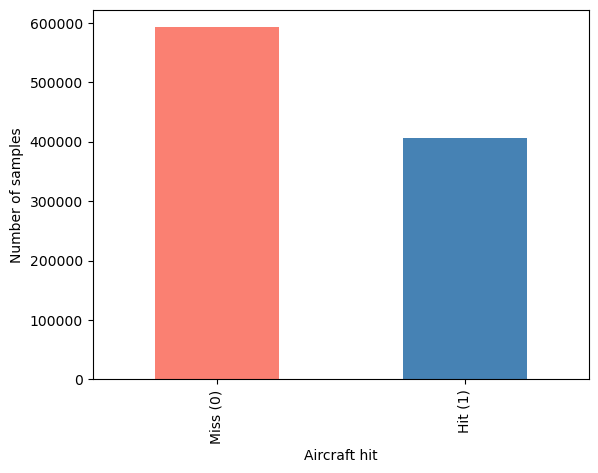

In [16]:
# Visulaizing the hit and miss
aircraft_df['hit'].value_counts().plot(kind='bar',
                                       color=['salmon', 'steelblue'],
                                       xlabel='Aircraft hit',
                                       ylabel='Number of samples')
plt.xticks([0, 1], ["Miss (0)", "Hit (1)"]);

### **Distribution among Categorical Data**

In [17]:
# Checking the distribution along Categorical columns
cat_columns = ['missile_phase', 'your_maneuverability',
               'enemy_generation', 'countermeasure_deployed']

for feature in cat_columns:
    print(aircraft_df[feature].value_counts())
    print('\n')

missile_phase
2    339642
0    329914
1    329849
Name: count, dtype: int64


your_maneuverability
2    333851
1    332852
0    332702
Name: count, dtype: int64


enemy_generation
4.0    489778
4.5    215634
5.0    215614
3.5     78379
Name: count, dtype: int64


countermeasure_deployed
1    500090
0    499315
Name: count, dtype: int64




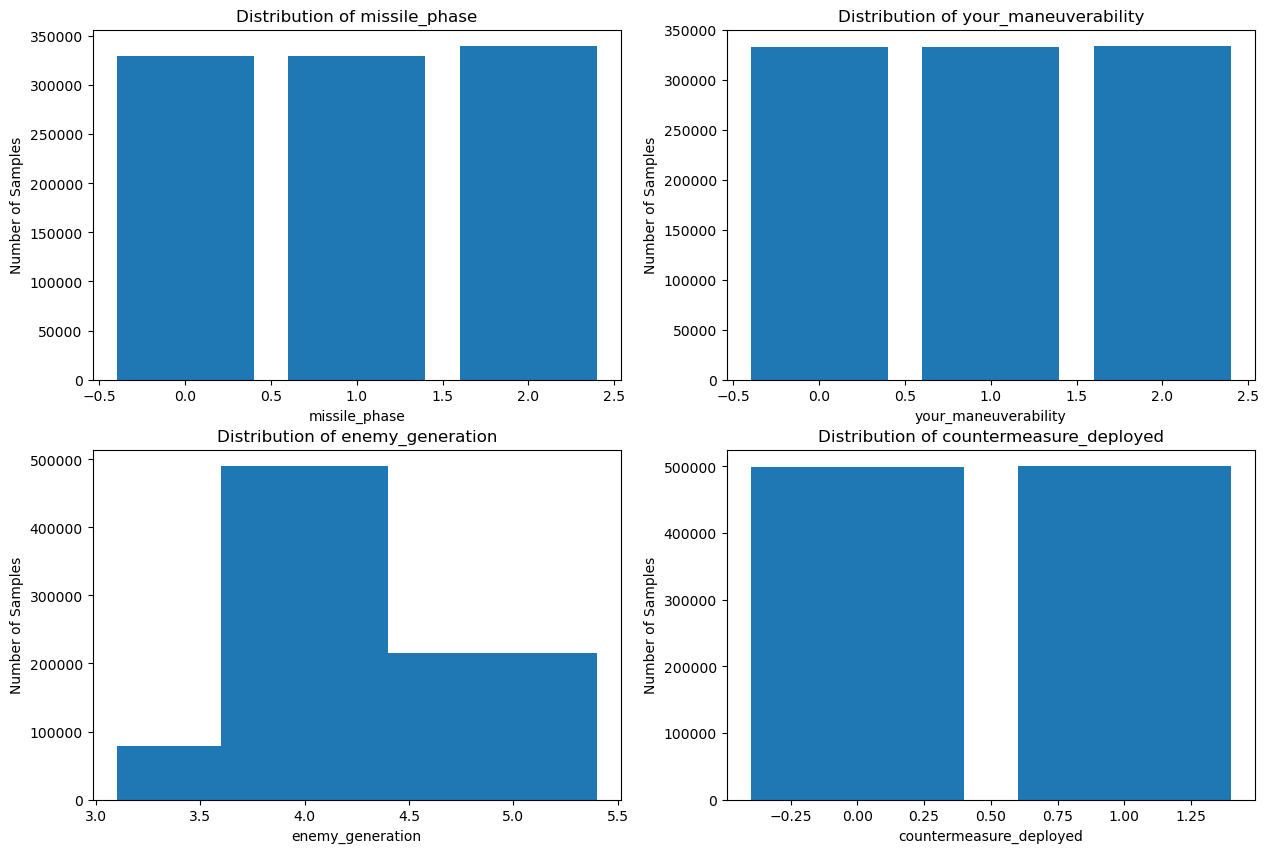

In [18]:
# Visualizing the Categorical data

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

for i, feature in enumerate(cat_columns):
    counts = aircraft_df[feature].value_counts()
    ax[i//2, i%2].bar(counts.index, counts.values)
    ax[i//2, i%2].set_title(f'Distribution of {feature}')
    ax[i//2, i%2].set_xlabel(feature)
    ax[i//2, i%2].set_ylabel("Number of Samples")

### **Distribution among Contineous features**

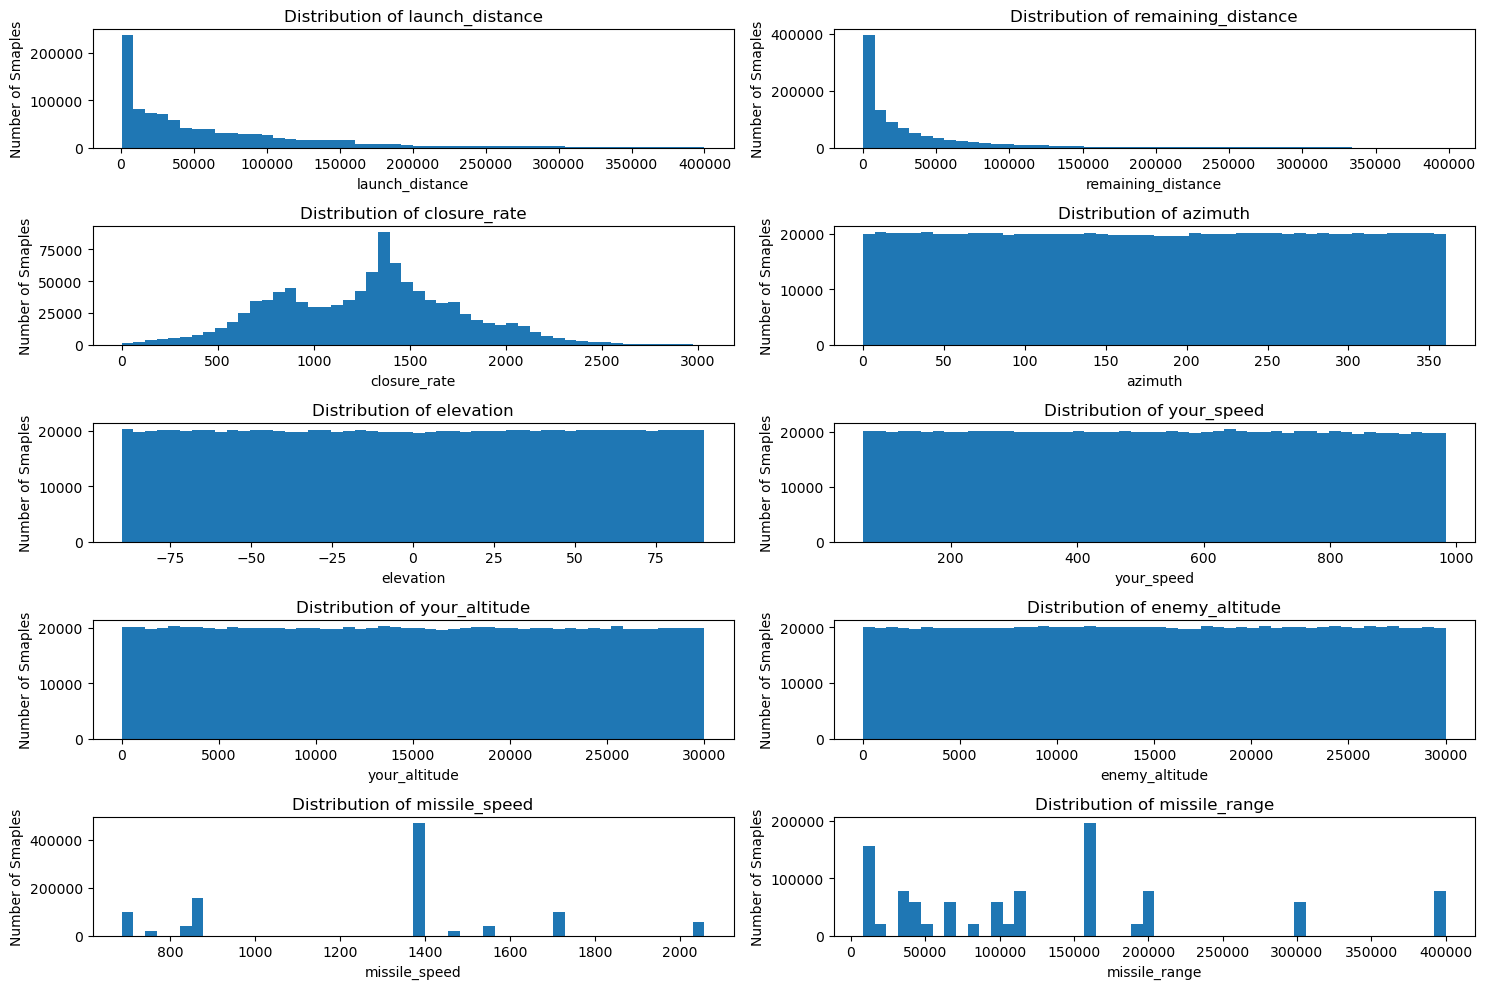

In [19]:
# distribution plots for the continuous features

cont_columns = ['launch_distance', 'remaining_distance', 'closure_rate',
                'azimuth', 'elevation', 'your_speed', 'your_altitude',
                'enemy_altitude', 'missile_speed', 'missile_range']

fig, ax = plt.subplots(5, 2, figsize=(15, 10))

for i, feature in enumerate(cont_columns):
    ax[i//2, i%2].hist(aircraft_df[feature], bins=50)
    ax[i//2, i%2].set_title(f"Distribution of {feature}")
    ax[i//2, i%2].set_xlabel(feature)
    ax[i//2, i%2].set_ylabel("Number of Smaples")
    
plt.tight_layout()
plt.show();

### **Correlation between Independent varibales**

A correlation matrix is a table that shows how strongly every numeric column is related to every other numeric column.

- Each value is between **−1** and **+1**
  - **`+1:`** perfect positive relation. When one increases, the other also increases.

  - **`0:`** no linear relation. No clear straight-line relationship.

  - **`−1:`** perfect negative relation. When one increases, the other decreases.

Here quickly finding which features are related to our target variable **`hit`**

In [20]:
# Correlational Matrix
corr = aircraft_df.corr()

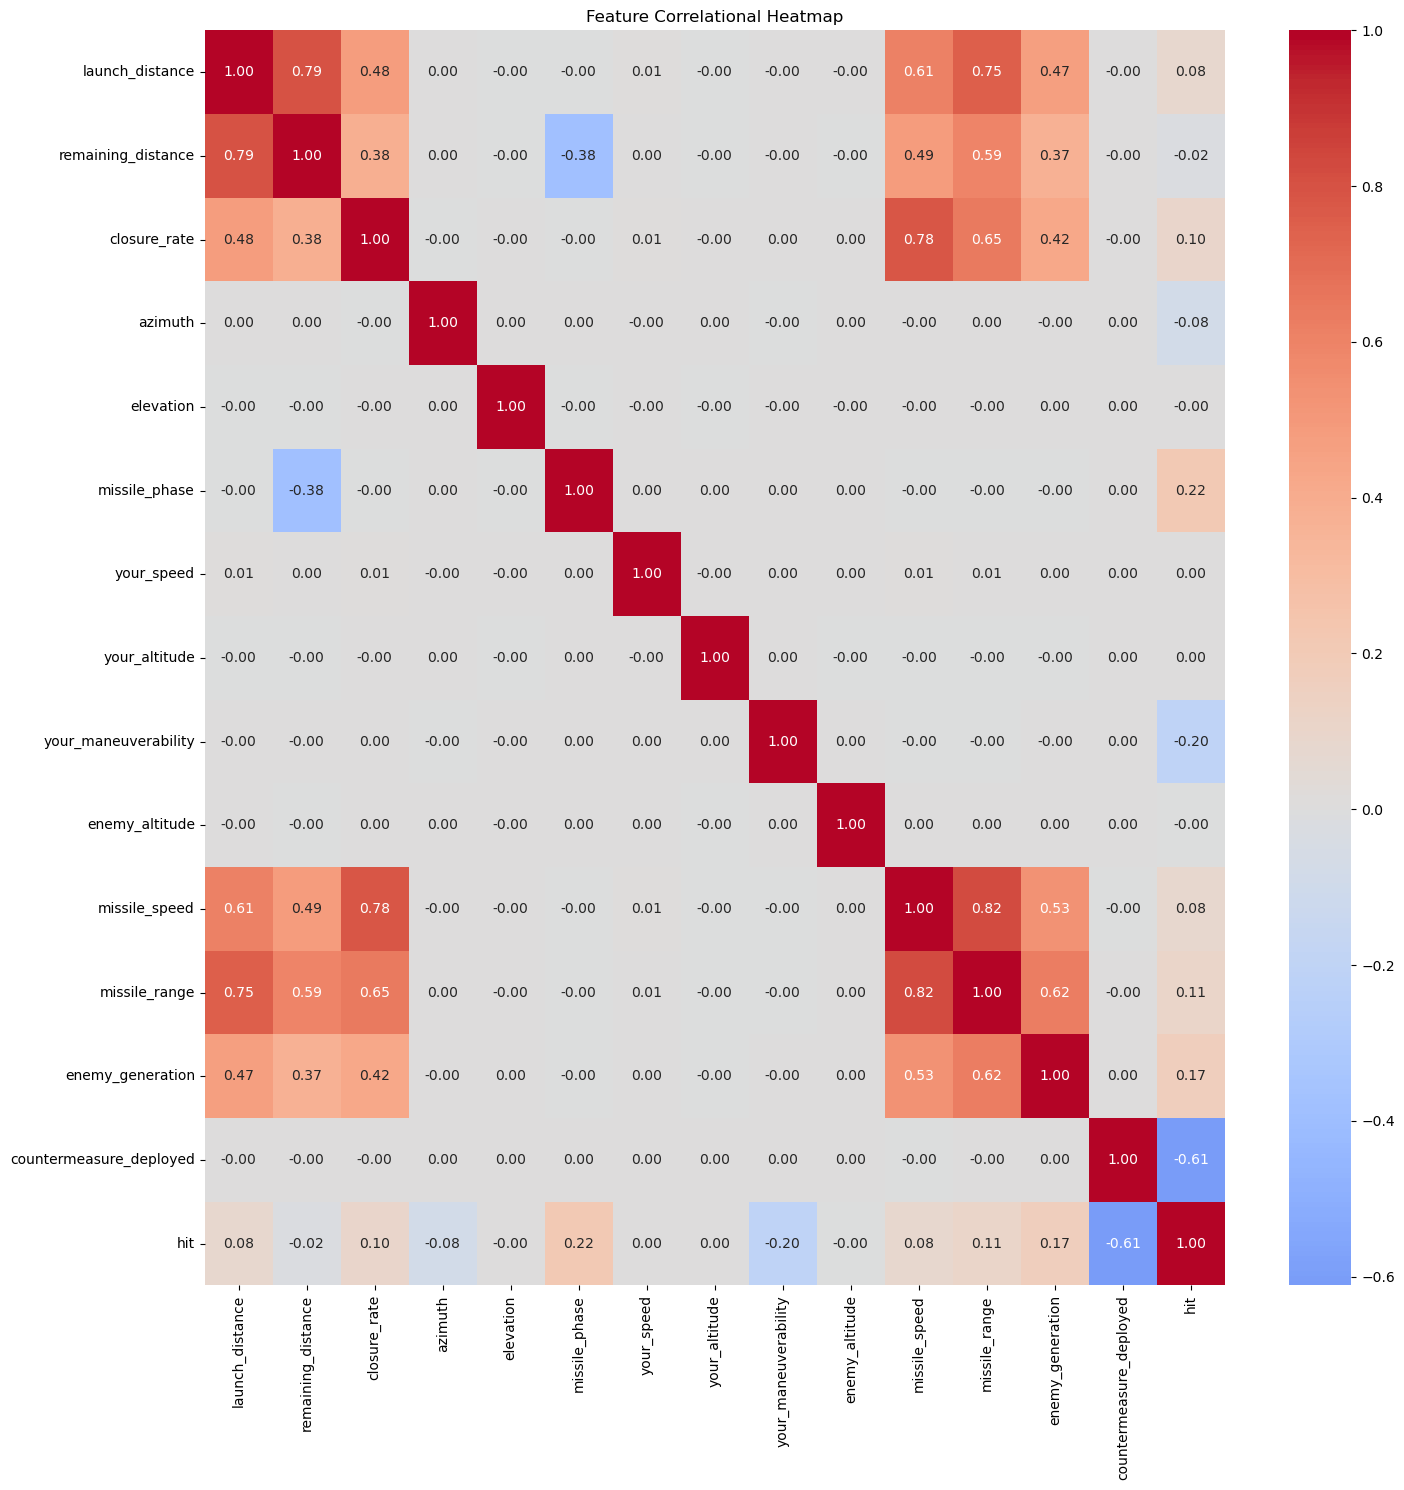

In [21]:
# Ploting the heatmap of correlational matrix

import seaborn as sns

plt.figure(figsize=(15, 15)) # Since there are 14 feature and 1 target variables
sns.heatmap(corr,
            annot=True,      # Adds numbers inside each heatmap cell
            fmt='.2f',       # Formats annotation text
            cmap='coolwarm',
            center=0)        # make 0 correlation appear as white, not skewed by data range

plt.title('Feature Correlational Heatmap')
plt.tight_layout()
plt.show();


# coolwarm means:

# blue = negative correlation
# red = positive correlation
# white/gray = near zero

# So visually:

# strong positive → deep red
# strong negative → deep blue
# weak/no relation → neutral

### **Countplots - Categorical Features by Hit Outcome**

#### **What is a Countplot?**
A countplot is a bar chart that shows how many samples fall into each category, split by a second variable using color. It is better suited than a boxplot for discrete integer features because it shows actual counts rather than trying to summarize a continuous distribution.

#### **Why are we using it here?**
- **We want to know:** for each value of a categorical feature, do hits and misses occur at different rates?

- `hit` is our binary target (0=miss, 1=hit).

- The `hue='hit'` parameter splits each bar by outcome, so you can directly compare how many hits vs misses occur at each category value.

#### **How to read a Countplot**
Each group on the x-axis is one category value (e.g. missile_phase = 0, 1, 2).
Within each group there are two bars: one for hit=0 (miss) and one for hit=1 (hit).

- If the hit bar is taller than the miss bar in a category, that category is associated with more hits.
- If the miss bar dominates, that category is associated with more misses.
- If both bars are roughly equal across all categories, the feature does not meaningfully separate hit from miss.

#### **What we are checking here**
Whether hit and miss counts shift meaningfully across category values.
Features checked: `missile_phase`, `your_maneuverability`, `countermeasure_deployed`, `enemy_generation`.

Expected behaviour:
- `missile_phase` 2 (terminal) → more hits (seeker locked, hardest to evade)
- `countermeasure_deployed` 1 → more misses (countermeasures actively reduce hit probability)
- `enemy_generation` 5 → more hits (advanced missiles with HOBS and ECCM)
- `your_maneuverability` 2 → more misses (more evasion options available)

If the hit and miss bars for a feature shift noticeably across category values, that feature is discriminative. If they stay proportionally the same across all values, the feature contributes less to separating the two classes.

In [22]:
cat_columns

['missile_phase',
 'your_maneuverability',
 'enemy_generation',
 'countermeasure_deployed']

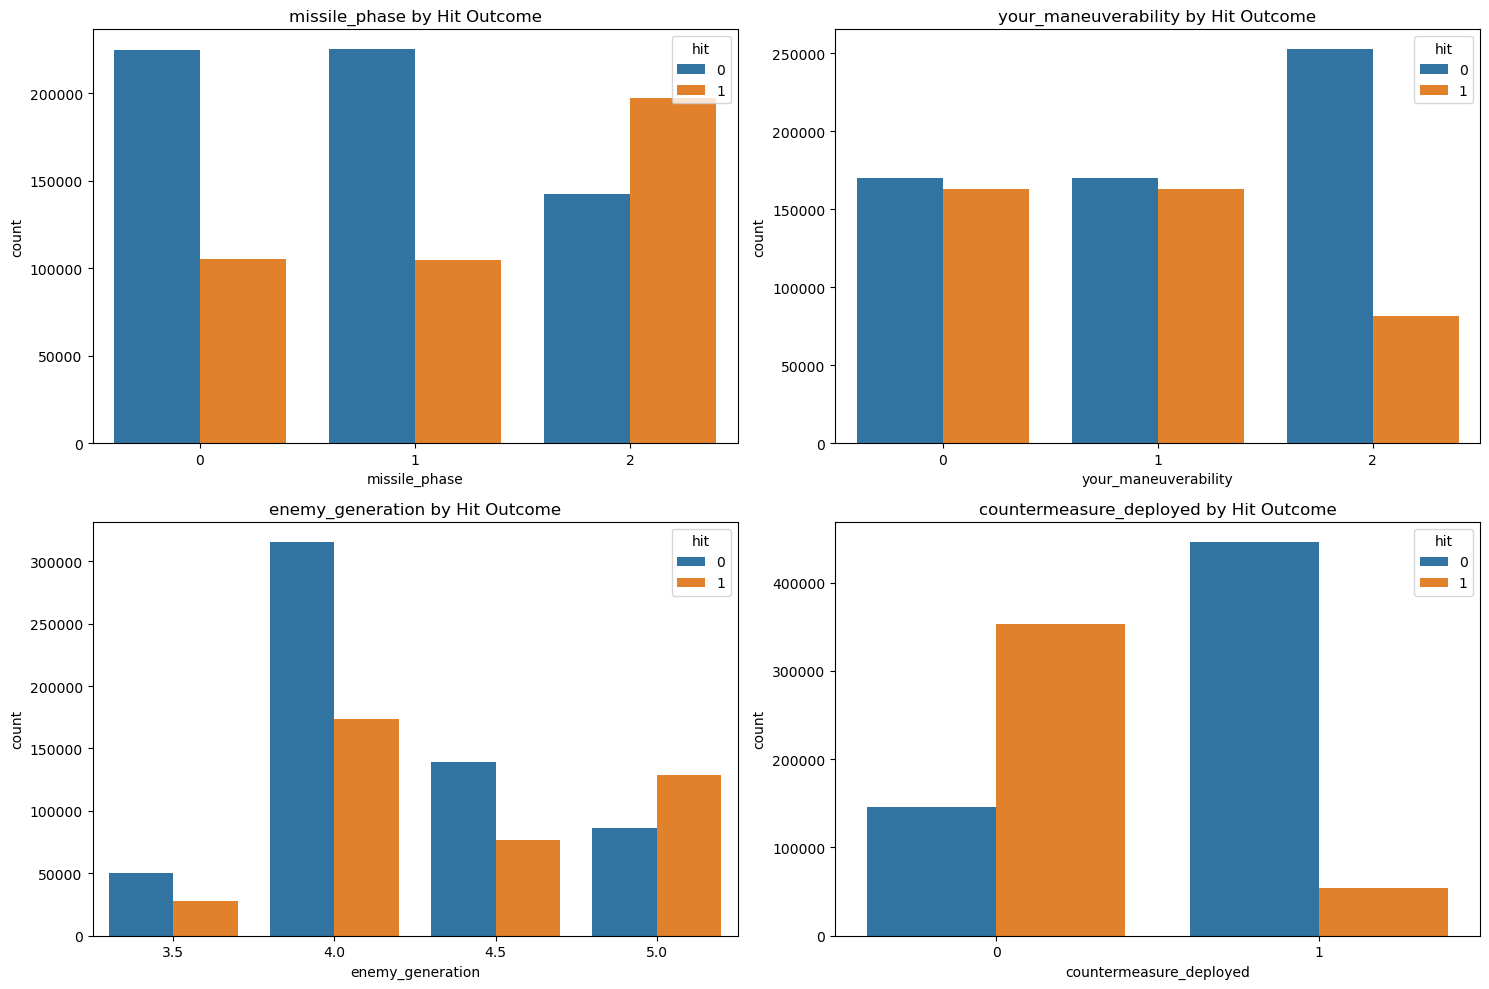

In [23]:
# Plotting Boxplot between hit/miss and categorical data

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

for i, feature in enumerate(cat_columns):
    sns.countplot(x=feature, hue='hit', data=aircraft_df, ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f"{feature} by Hit Outcome")
    
plt.tight_layout()
plt.show();

In [24]:
# Checking for outliers
aircraft_df[cont_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
launch_distance,999405.0,65013.755552,74170.064429,500.024387,9739.140529,37354.954850,94130.643570,399998.390200
remaining_distance,999405.0,32542.830822,46805.403792,0.002412,3404.931449,13994.035580,42330.875730,397823.101500
closure_rate,999405.0,1276.555065,467.511980,0.206626,907.111492,1324.890219,1569.283500,3033.120274
azimuth,999405.0,179.937820,104.078646,0.001255,89.627150,179.910579,270.177444,359.998621
elevation,999405.0,0.025930,52.051722,-89.999940,-45.155190,0.032270,45.171235,89.999688
your_speed,999405.0,520.993280,265.924147,61.000864,290.638551,520.832276,750.908502,982.998755
your_altitude,999405.0,14984.533823,8666.247323,0.008947,7468.446199,14971.837290,22489.231270,29999.961160
enemy_altitude,999405.0,15009.353638,8657.791088,0.036823,7532.486649,14998.463830,22511.722400,29999.936050
missile_speed,999405.0,1274.093497,370.223841,686.000000,857.000000,1372.000000,1372.000000,2058.000000
missile_range,999405.0,129474.970608,111043.200468,8000.000000,35000.000000,110000.000000,160000.000000,400000.000000


### **🧾 What we covered**
- Shape, nulls, dtypes confirmed
- Class balance checked
- Categorical distributions inspected
- Histograms for all continuous features
- Correlation heatmap
- Countplots: hit outcome by missile_phase, your_maneuverability, countermeasure_deployed, enemy_generation
- Outlier check on continuous features

### **Key Findings**

- **Class balance** is 59% miss, 41% hit. No imbalance handling needed. SMOTE and class weights both ruled out.

- **countermeasure_deployed** is the dominant feature by a large margin (r=0.61 with hit). Deploying countermeasures overwhelmingly shifts outcomes toward misses. May reflect near-deterministic simulator logic. SHAP will confirm after training.

- **missile_phase** shows clean separation: phase 2 (terminal) is strongly associated with hits. Physically correct since a seeker-locked missile is hardest to evade.

- **your_maneuverability** shows meaningful separation: category 2 is associated with far more misses. Negative correlation (r=0.20) confirmed. Evasive capability reduces hit probability in the simulator.

- **enemy_generation** shows mild separation toward hits at generation 5.0. Tied to more capable missile packages in the metadata CSV rather than aircraft speed directly.

- **missile_speed and missile_range** are tightly coupled (r=0.82). Both show discrete spikes confirming fixed missile template behavior. Tree models handle this fine but SHAP may split credit between them artificially.

- **your_speed, your_altitude, enemy_altitude** show near-zero correlation with hit. Known simulator limitation: the physics generator did not fully use these features. They remain in the feature set since it is locked.

- **remaining_distance** shows near-zero correlation with hit despite being the strongest predictor in Stage 4. Different question: distance determines when the missile arrives, not whether it hits.

- **No outliers or data quality issues** found in continuous features. All values sit within physically sensible ranges after the 300s filter.

---

### **Evaluation Plan (decided during EDA)**

- **Primary metrics:** Recall > 0.90, F1 > 0.85, ROC-AUC > 0.95. Recall is prioritised because missing a real hit is more costly than a false alarm.

- **Confusion matrix:** Shows true positives, false positives, true negatives, false negatives. Lets us see exactly where the model is making mistakes, not just an aggregate score.

- **ROC curve:** Plots true positive rate vs false positive rate across all classification thresholds. Area under the curve (AUC) summarises overall discrimination ability. Target: > 0.95.

- **Feature importance plot:** Shows which features the model relied on most overall. Expected to be dominated by countermeasure_deployed and missile_phase.

- **SHAP analysis:** Goes deeper than feature importance. For each individual prediction, SHAP shows how much each feature pushed the prediction toward hit or miss. Will confirm whether countermeasure_deployed is behaving as a near-rule or a soft probabilistic influence.

- **High performance is expected** given the synthetic rule-driven data. R² above 0.95 and recall above 0.90 are realistic targets, not signs of a bug.
---

## **8. Train/Val/Test Split and Baseline Models**

### **Split Strategy**
- Train: 70%, Val: 15%, Test: 15%
- Random split, random_state=42 for reproducibility
- X = all features except hit
- y = hit (binary: 0 = miss, 1 = hit)
- Stratify on y to preserve 59/41 class ratio across all splits

### **Baseline Models**
Train all three in one loop using a dictionary, compare results side by side.

**Models to compare:**
- Random Forest
- XGBoost
- LightGBM

### **Evaluation Metrics**
- Recall (primary -- minimise missed hits)
- F1 Score (balance precision and recall)
- ROC-AUC (overall discrimination ability)

### **After Baseline**
- Confusion matrix for each model (see exactly where mistakes are made)
- ROC curve overlay for all three models on one plot
- Feature importance plot
- SHAP analysis (confirm whether countermeasure_deployed is near-deterministic or soft probabilistic)
- No threshold tuning at baseline stage -- default 0.5 threshold throughout

In [25]:
# Checking the number of columns before split
len(aircraft_df.columns), len(aircraft_df)

(15, 999405)

In [26]:
# # Splitting the data into train, validation and test dataset

# from sklearn.model_selection import train_test_split

# # 1. 70% train and 30% temp data
# train_df, temp_df = train_test_split(aircraft_df,
#                                      test_size=0.3,
#                                      stratify=aircraft_df['hit'],  # preserve 59/41 class ratio across splits
#                                      random_state=42)

# len(train_df), len(temp_df)

In [27]:
# # 2. Split temp data into validation (15%) and test data (15%)
# val_df, test_df = train_test_split(temp_df,
#                                    test_size=0.5,
#                                    stratify=temp_df['hit'],   # preserve 59/41 class ratio across splits
#                                    random_state=42)

# len(val_df), len(test_df)

In [28]:
# # 3. Resetting the indices

# train_df = train_df.reset_index(drop=True)
# val_df = val_df.reset_index(drop=True)
# test_df = test_df.reset_index(drop=True)

In [29]:
# train_df.head()

In [30]:
# val_df.head()

In [31]:
# test_df.head()

In [32]:
# train_df['hit'].value_counts(normalize=True)

In [33]:
# val_df['hit'].value_counts(normalize=True)

In [34]:
# test_df['hit'].value_counts(normalize=True)

In [35]:
# Reuse environment-aware paths defined earlier
DATA_ROOT, HIT_DATA_ROOT

(PosixPath('/mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data'),
 PosixPath('/mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data/hit'))

In [36]:
# # Saving the datset split in parquet form 

# from pathlib import Path

# # Making the data folder for Hit data
# Path(HIT_DATA_ROOT).mkdir(parents=True, exist_ok=True)

# # Saving the data
# print("Starting saving the data... wait")

# train_df.to_parquet(HIT_DATA_ROOT / "train.parquet", engine="auto", index=False)
# val_df.to_parquet(HIT_DATA_ROOT / "val.parquet", engine="auto", index=False)
# test_df.to_parquet(HIT_DATA_ROOT/ "test.parquet", engine="auto", index=False)

# print(f"Saved the data at {HIT_DATA_ROOT}")

In [37]:
# Load the parquet files back

print("Loading the saved data... wait")

train_df = pd.read_parquet(HIT_DATA_ROOT / "train.parquet", engine="auto")
val_df = pd.read_parquet(HIT_DATA_ROOT/ "val.parquet", engine="auto")
test_df = pd.read_parquet(HIT_DATA_ROOT / "test.parquet", engine="auto")

print(f"Train: {len(train_df):,} rows, {train_df.shape[1]} cols")
print(f"Val: {len(val_df):,} rows, {val_df.shape[1]} cols")
print(f"Test: {len(test_df):,} rows, {test_df.shape[1]} cols")

# Confirm index starts from 0
print(f"\nTrain index start: {train_df.index[0]}")
print(f"Val index start: {val_df.index[0]}")

print(f"Loaded dataset from {HIT_DATA_ROOT}")

Loading the saved data... wait
Train: 699,583 rows, 15 cols
Val: 149,911 rows, 15 cols
Test: 149,911 rows, 15 cols

Train index start: 0
Val index start: 0
Loaded dataset from /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data/hit


In [38]:
# Function to split data into X and y 

def get_X_and_y(df):
    X = df.drop(columns=['hit'])
    y = df['hit']
    
    return X, y

# Splitting the features and target
X_train, y_train = get_X_and_y(train_df)
X_val, y_val = get_X_and_y(val_df)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"y_val: {y_val.shape}")

X_train: (699583, 14)
y_train: (699583,)
X_val: (149911, 14)
y_val: (149911,)


### **8.1 Models Selected for Hit Classification**

**1) Why Tree-Based Models**

The synthetic engagement data has non-linear relationships between features (e.g. `missile_phase` and `hit` shift sharply at terminal phase) and mixed feature types (continuous, ordinal, binary). Tree-based models handle both naturally no scaling, no encoding needed.

**2) Models**

- **[Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)**

    Builds many independent decision trees on random subsets of data, takes a majority vote across them. Robust baseline, resistant to overfitting, good at capturing feature interactions.

- **[XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier)**

    Builds trees sequentially each tree corrects the errors of the previous one (gradient boosting). Faster and more accurate than Random Forest on structured data. GPU-accelerated via `device="cuda"`.

- **[LightGBM](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html)**

    Same gradient boosting approach as XGBoost but uses histogram-based splitting significantly faster on large datasets (699k rows). GPU-accelerated via `device_type="cuda"`.

**3) Why Not Logistic Regression**

Logistic regression assumes a linear decision boundary when one feature changes, the probability shifts by the same fixed amount every time.

`hit` is non-linear by design. The difference between `missile_phase=1` and `missile_phase=2` is not the same as between `missile_phase=0` and `missile_phase=1`. Countermeasures interact with maneuverability in ways that a straight line cannot capture. Logistic regression will miss these interactions and underperform at both extremes of the threat range.

Tree-based models don't assume any boundary shape. They split data into buckets and learn the decision surface directly from the data.

**4) Why Not a Neural Network**

Overkill for structured tabular data at this stage. Tree-based models consistently match or outperform neural networks on tabular data and train in a fraction of the time. Neural networks also require more tuning. If **ROC-AUC < 0.90 after tuning, revisit.**

In [39]:
# Import the classifiers
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Store the models in a dictionary for easy training
model_dict = {
    # Standard CPU-based mode
    "RandomForestClassifier" : RandomForestClassifier(n_jobs=-1),   # Use all the computational power available
    
    # GPU-accelerated model
    "XGBClassifier"          : XGBClassifier(device="cuda"),
    
    # GPU-accelerated model (using official parameter)
    "LGBMClassifier"         : LGBMClassifier(device_type="cuda")
}

In [40]:
# Function to fit the model and evaluate them 
from sklearn.metrics import recall_score, f1_score, roc_auc_score
import time

def train_and_get_score(model_dict, X_train, y_train, X_val, y_val):
    """
    Trains multiple classification models and evaluates them on a validation set.

    Args:
        models_dict (dict): Dictionary of {model_name: model_instance} pairs.
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training labels.
        X_val (pd.DataFrame): Validation features.
        y_val (pd.Series): Validation labels.

    Returns:
        dict: Nested dictionary of {model_name: {recall, f1, roc_auc, train_time}}.
    """

    results = {}
    
    for name, model in model_dict.items():
        
        # Start the time to calculate the time to train the model
        start = time.time()
        print(f"Training {name}...")
        
        # Fit the model
        model.fit(X_train, y_train)
        
        # Total time elasped while training
        elapsed = time.time() - start
        print(f"Model trained successfully. Took {elapsed:.2f}s")
        
        # Predict on model trained
        print("Predicting with trained model...")
        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val)
        
        # Calculate the metrics
        recall = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        # ROC-AUC needs probability scores (not hard 0/1 predictions) to measure ranking ability across all thresholds
        # [:, 1] selects the probability of class 1 (hit)
        roc_auc = roc_auc_score(y_val, y_pred_proba[:,1])
        
        # Appending the results
        print("Appending the results...")
        results[name] = {
            "recall_score" : recall,
            "f1_score" : f1,
            "roc_auc_score" : roc_auc,
            "time"          : elapsed
        }
        print("Model scoring done.")
        print(f"    Recall: {recall:.4%} | F1_score: {f1:.4%} | ROC_AUC_score: {roc_auc:.4%}")
        
    return results

In [41]:
# # Training the baseline model with default attributes

# result = train_and_get_score(
#     model_dict=model_dict,
#     X_train=X_train,
#     y_train=y_train,
#     X_val=X_val,
#     y_val=y_val
# )

In [42]:
# result

In [43]:
# # Converting the results into Dataframe

# results_baseline = pd.DataFrame(index=result.keys(), data=result.values())
# results_baseline

In [44]:
# # Save the results for baseline
# results_baseline.to_csv(HIT_DATA_ROOT / "hit_baseline_predictions.csv", index=True)

In [45]:
# Load the predictions
baseline_predictions = pd.read_csv(HIT_DATA_ROOT / "hit_baseline_predictions.csv", index_col=0)
baseline_predictions

,recall_score,f1_score,roc_auc_score
RandomForestClassifier,0.941985,0.967548,0.998795
XGBClassifier,0.996692,0.996660,0.999933
LGBMClassifier,0.992402,0.994805,0.999901


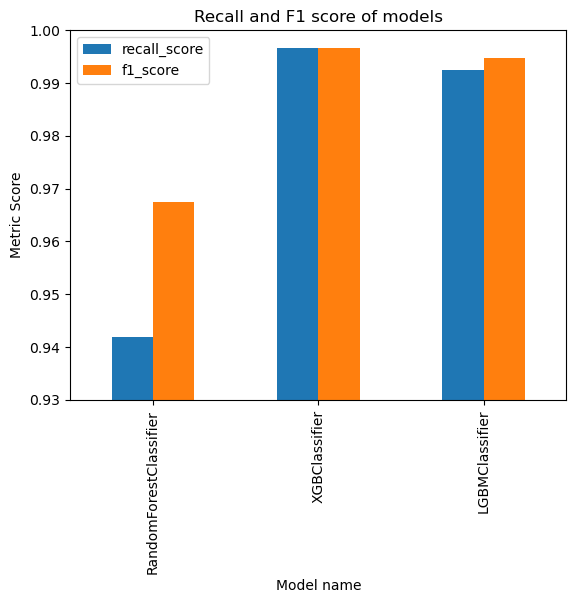

In [46]:
# Plotting the prictions sideways for comparison

# recall and f1 score side by side
baseline_predictions[['recall_score', 'f1_score']].plot(kind="bar")
plt.ylim(0.93, 1.0)
plt.title("Recall and F1 score of models")
plt.xlabel("Model name")
plt.ylabel("Metric Score")
plt.legend()
plt.show();

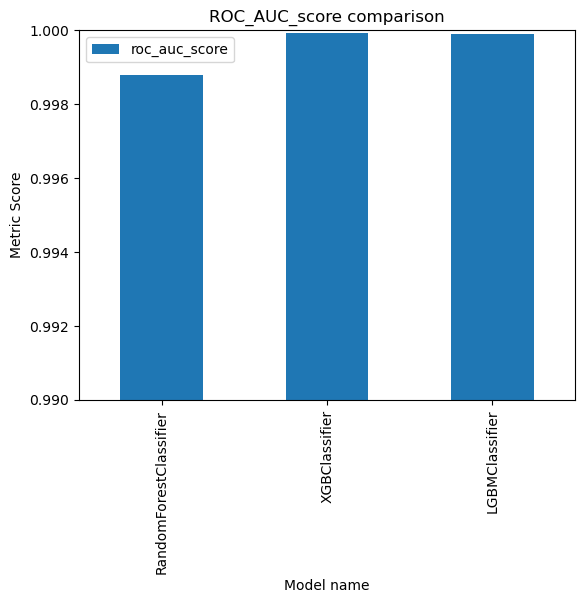

In [47]:
# Comparing ROC_AUC_score side by side
baseline_predictions['roc_auc_score'].plot(kind="bar")
plt.title("ROC_AUC_score comparison")
plt.xlabel("Model name")
plt.ylabel("Metric Score")
plt.ylim(0.99, 1)
plt.legend()
plt.show();

### **8.2 Baseline Results (default hyperparameters, no tuning)**

| Model | Recall | F1 | ROC-AUC | Train Time |
|---|---|---|---|---|
| RandomForestClassifier | 94.20% | 96.75% | 99.88% | 46.90s |
| XGBClassifier | 99.67% | 99.67% | 99.99% | 3.59s |
| LGBMClassifier | 99.24% | 99.48% | 99.99% | 4.62s |

### **Decision: [XGBoost](https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBClassifier)**

**Chosen over Random Forest because:**
- RF trails on all three metrics at baseline → lower recall, lower F1, lower ROC-AUC
- **XGBoost has `40+` tunable parameters** vs **RF's `18`** → more room to improve with tuning
- GPU acceleration means Optuna runs significantly faster on XGBoost
- Recall is the primary metric → XGBoost leads at 99.67% vs RF's 94.20%
- Industry standard for tabular data in critical systems → better explainability via SHAP
- In defense systems, explainability matters → SHAP shows exactly which features drove each prediction

**Chosen over LightGBM because:**
- XGBoost beats LightGBM on all three metrics at baseline
- LightGBM flagged a sparse features CUDA warning → less reliable on this dataset
- XGBoost trained faster at 3.59s vs 4.62s

### **Expected outcome after tuning**
XGBoost recall and F1 should hold or improve, with ROC-AUC remaining near-perfect. Primary tuning goal is confirming the model has not overfitted to simulator rules.

---

### **8.3 Hyperparameter Tuning Skipped**

XGBoost reached 99.67% recall, 99.67% F1, and 99.99% ROC-AUC at default parameters.

Tuning 400+ Optuna trials for a sub-0.1% potential gain has no practical benefit here.

**Decision: skip tuning, proceed directly to cross-validation to confirm stability.**

In [48]:
# Checking up the data
len(X_train), len(y_train)

(699583, 699583)

In [50]:
# Train the final model
from xgboost import XGBClassifier

# 1. Instantiate the model
model = XGBClassifier(device="cuda", tree_method="hist", random_state=42)

# 2. Train the model
print("Training in progress...")
model.fit(X_train, y_train)

# 3. Predictions and predictions probabilities
print("Training done... Prediction on going...")
y_preds = model.predict(X_val)
y_pred_probas = model.predict_proba(X_val)
print("All done")

Training in progress...
Training done... Prediction on going...
All done


In [51]:
# Checking out preds
y_preds

array([1, 0, 1, ..., 0, 0, 0])

In [53]:
# Checking out pred probabilities
y_pred_probas                      # [Miss(0), Hit(1)]

array([[5.3983927e-04, 9.9946016e-01],
       [9.9999744e-01, 2.5739714e-06],
       [8.0949068e-04, 9.9919051e-01],
       ...,
       [1.0000000e+00, 2.7091971e-08],
       [9.2038119e-01, 7.9618819e-02],
       [9.9315071e-01, 6.8492866e-03]], dtype=float32)

### **Summary**

- **Final XGBoost classifier** trained on **699,583 rows** with **default hyperparameters.**
  
- GPU training via `device='cuda'` and `tree_method='hist'`
  
- Hyperparameter tuning skipped since baseline scores already exceed all evaluation thresholds.

- Proceeding to cross-validation to confirm stability.
  
---

## **9. Cross-Validation**

Our val scores so far came from one fixed 15% split. That split could have been lucky because
an easy subset that made the model look better than it actually is.

**What cross-validation does**

- Divides the combined train + val set into 5 equal folds. 
- Each fold takes a turn as the
validation set while the other 4 train the model. Repeats 5 times for every row gets
evaluated exactly once. Test set stays locked throughout.

**What we're confirming here**

This is not retuning. Hyperparameter tuning was skipped entirely. Default XGBoost params
are fixed. We are purely checking whether the Section 8 scores were stable or a product
of a fortunate split.

At the end, we average scores across all 5 folds which is  a reliable, bias-free reality check
on how the final model actually generalises.

**Plan**
1. Load train and val parquets (already loaded)
2. Combine into a temporary dataframe
3. Separate into X and y
4. Define a `cross_validate_model` function — takes X, y, cv=5
5. Inside the function: train a fresh `XGBClassifier` each fold using `StratifiedKFold`,
   compute `Recall`, `F1`, and `ROC-AUC` per fold, print per-fold results
6. After all folds, average and print final summary.

In [59]:
# Checking our training data 
train_df.head()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,hit
0,55165.903660,49340.341120,1434.336528,298.862232,76.854523,0,567.837101,974.992081,2,25845.425760,1372,80000,4.0,0,0
1,28745.910170,4852.588251,1214.708066,219.398861,0.173912,2,203.550222,25717.200140,1,2583.928379,1372,100000,4.5,1,0
2,6175.014855,868.337205,929.315766,55.888821,79.677652,2,819.163554,16923.877510,0,3651.367587,847,8000,3.5,0,1
3,39630.624850,18867.507530,2513.804075,36.204438,-31.212132,1,660.473290,3522.341576,0,6948.906263,2058,100000,4.0,0,1
4,44895.469460,41715.763780,917.678459,188.340646,-44.462236,0,643.366006,10836.361010,0,25143.619470,1372,160000,5.0,1,0


In [58]:
# Checking the validation data 
val_df.head()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,hit
0,18189.612030,7574.503990,677.222436,179.362608,-63.175880,1,398.420818,9625.408402,1,20009.84614,857,35000,4.0,0,1
1,2800.377403,1074.382532,206.105656,127.912523,6.143458,1,785.515925,13880.048650,1,16961.72040,686,8000,4.0,1,0
2,85377.255990,16429.585940,1288.531721,113.263225,45.019773,2,298.976982,14940.723250,1,12693.04158,1372,160000,5.0,1,1
3,61601.284660,58512.859810,1241.056419,112.006673,-54.288722,0,598.677800,26745.479970,1,16890.47642,1372,110000,4.0,1,0
4,59057.350360,43642.456620,719.502563,168.141834,-0.429135,0,666.744545,19668.554680,1,29273.89703,1372,110000,4.5,1,0


In [61]:
# Combine the dataframes
temp_df = pd.concat([train_df, val_df], ignore_index=True)
temp_df.head()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,hit
0,55165.903660,49340.341120,1434.336528,298.862232,76.854523,0,567.837101,974.992081,2,25845.425760,1372,80000,4.0,0,0
1,28745.910170,4852.588251,1214.708066,219.398861,0.173912,2,203.550222,25717.200140,1,2583.928379,1372,100000,4.5,1,0
2,6175.014855,868.337205,929.315766,55.888821,79.677652,2,819.163554,16923.877510,0,3651.367587,847,8000,3.5,0,1
3,39630.624850,18867.507530,2513.804075,36.204438,-31.212132,1,660.473290,3522.341576,0,6948.906263,2058,100000,4.0,0,1
4,44895.469460,41715.763780,917.678459,188.340646,-44.462236,0,643.366006,10836.361010,0,25143.619470,1372,160000,5.0,1,0


In [62]:
# Checking the shape of temp_df
temp_df.shape

(849494, 15)

In [63]:
# Splitting the data into X and y
X_temp, y_temp = get_X_and_y(temp_df)

# Checking the shape of Split X and y
X_temp.shape, y_temp.shape

((849494, 14), (849494,))

In [64]:
# Function to call the cross_validation on model
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

def cross_validate_model(X, y, cv=5):
    """
    Runs stratified k-fold cross-validation on a default XGBClassifier.

    Trains a fresh model on each fold and evaluates Recall, F1, and ROC-AUC.
    Prints per-fold results and a final averaged summary across all folds.

    Args:
        X (pd.DataFrame): Feature matrix - combined train + val set.
        y (pd.Series): Binary target column (0 = miss, 1 = hit).
        cv (int, optional): Number of folds. Defaults to 5.
    """
    
    # Define custom parameters using the StratifiedKFold
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    # Empty lists to store each fold's metrics
    recall_scores = []
    f1_scores = []
    roc_auc_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)): # gives index arrays
        
        # 1. Slice X and y using train_idx and val_idx
        X_train_fold = X.iloc[train_idx]              # iloc returns a DataFrame/Series
        y_train_fold = y.iloc[train_idx]
        
        X_val_fold = X.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]
        
        # 2. Initialize fresh XGBRegressor with default paramaters
        model = XGBClassifier(device="cuda",
                              tree_method="hist",
                              random_state=42)
        
        # 3. Fit on train fold
        model.fit(X_train_fold, y_train_fold)
        
        # 4. Predict on val fold
        y_preds = model.predict(X_val_fold)
        y_pred_probas_hit = model.predict_proba(X_val_fold)[:, 1]
        
        # 5. Compute all metrics and append to lists
        recall = recall_score(y_val_fold, y_preds)
        f1 = f1_score(y_val_fold, y_preds)
        roc_auc = roc_auc_score(y_val_fold, y_pred_probas_hit)
        
        recall_scores.append(recall)
        f1_scores.append(f1)
        roc_auc_scores.append(roc_auc)
        
        # 6. Print this fold's results
        print(f"Fold: {fold}")
        print(f"    Recall:         {recall:.4f}")
        print(f"    F1_score:       {f1:.4f}")
        print(f"    ROC_AUC_score:  {roc_auc:.4f}")
        
    # After loop - print averages of all lists
    print("Average fold values...")
    print(f"    Average Recall:         {np.mean(recall_scores):.4f}")
    print(f"    Average F1_score:       {np.mean(f1_scores):.4f}")
    print(f"    Average ROC_AUC_score:  {np.mean(roc_auc_scores):.4f}")
        

In [65]:
# Running the 5-fold cross-validation on XGBClassifier
cross_validate_model(
    X=X_temp,
    y=y_temp,
    cv=5
)

Fold: 0
    Recall:         0.9971
    F1_score:       0.9968
    ROC_AUC_score:  0.9999
Fold: 1
    Recall:         0.9966
    F1_score:       0.9966
    ROC_AUC_score:  0.9999
Fold: 2
    Recall:         0.9966
    F1_score:       0.9967
    ROC_AUC_score:  0.9999
Fold: 3
    Recall:         0.9969
    F1_score:       0.9966
    ROC_AUC_score:  0.9999
Fold: 4
    Recall:         0.9971
    F1_score:       0.9968
    ROC_AUC_score:  0.9999
Average fold values...
    Average Recall:         0.9969
    Average F1_score:       0.9967
    Average ROC_AUC_score:  0.9999


### **Cross-Validation Results**

**Why a single validation split isn't enough**
Our val scores so far came from one fixed 15% split. That split could have been lucky,
an easy subset that made the model look better than it actually is.

**What we did**
- Combined train + val into a temporary dataset (~849k rows)
- Ran 5-fold stratified CV using default XGBoost params no tuning, purely a stability check
- Each fold trained a fresh XGBClassifier on 80% and evaluated on the remaining 20%
- StratifiedKFold used to preserve class ratio (59% miss, 41% hit) across all folds
- Test set stayed locked throughout

---

**Per-fold results**

| Fold | Recall | F1     | ROC-AUC |
|------|--------|--------|---------|
| 0    | 0.9971 | 0.9968 | 0.9999  |
| 1    | 0.9966 | 0.9966 | 0.9999  |
| 2    | 0.9966 | 0.9967 | 0.9999  |
| 3    | 0.9969 | 0.9966 | 0.9999  |
| 4    | 0.9971 | 0.9968 | 0.9999  |
| **Avg** | **0.9969** | **0.9967** | **0.9999** |

---

**CV averages vs baseline validation scores**

| Metric  | Baseline (single split) | CV Average | Status |
|---------|-------------------------|------------|--------|
| Recall  | 0.9967                  | 0.9969     | ✅ Essentially identical |
| F1      | 0.9967                  | 0.9967     | ✅ No change             |
| ROC-AUC | 0.9999                  | 0.9999     | ✅ No change             |

---

**Verdict**

- ✅ Scores are consistent across all 5 folds since variance across folds is 0.0005 on Recall
- ✅ The baseline val scores were not a lucky split
- ✅ Model is stable and generalises cleanly across all data arrangements
- ✅ Near-perfect scores are expected since deterministic physics simulator produces
  clean, learnable decision boundaries

**The hit classifier is confirmed. Proceeding to final evaluation on the held-out test set.**

---

## **10. SHAP Analysis**

### **What is SHAP?**
SHapley Additive exPlanations. Math borrowed from game theory (Lloyd Shapley, 1953)
adapted for ML explainability.

### **What it solves**
Model predicts a probability. You have no idea why. SHAP breaks that prediction down
feature by feature for each individual row.

### **What a SHAP value is**
A number per feature per prediction. Answers: "by how much did this feature shift the
predicted hit probability away from the average?"
- **Positive = pushed hit probability up** (more likely to be hit)
- **Negative = pushed it down** (more likely to miss)

### **Base value**
Mean of all model predictions on training data. Your anchor point before any feature
information is known.

### **The formula**
`base_value + SHAP1 + SHAP2 + ... + SHAP14 = final prediction`

SHAP values are shifts, not predictions. Base value is the starting point.

### **vs Feature Importance**
- **Built-in importance:** global, no direction, can mislead.
- **SHAP:** per prediction, directional, mathematically fair. Industry standard.

---

**Section 10 Plan**

- 10.1 XGBoost built-in feature importance
- 10.2 SHAP global summary
- 10.3 SHAP single prediction breakdown

### **10.1 XGBoost Built-in Feature Importance**

XGBoost tracks how often each feature was used to split nodes across all trees. The more splits a feature causes, the higher its importance score.

Quick global signal. No direction, no per-prediction detail.

Will compare against SHAP in 12.2 to see where they agree and differ.

In [66]:
# Loading the feature importance scores
importance_score = model.feature_importances_

# Check the names of features
feature_names = np.array(X_train.columns.to_list())

importance_score, feature_names

(array([5.5235677e-04, 4.9871724e-04, 5.2154931e-04, 4.6946734e-02,
        6.5492265e-02, 8.5298859e-02, 5.7014480e-04, 4.1976046e-02,
        8.4364057e-02, 4.4101268e-02, 6.0281187e-04, 7.9618784e-04,
        9.0385064e-02, 5.3789395e-01], dtype=float32),
 array(['launch_distance', 'remaining_distance', 'closure_rate', 'azimuth',
        'elevation', 'missile_phase', 'your_speed', 'your_altitude',
        'your_maneuverability', 'enemy_altitude', 'missile_speed',
        'missile_range', 'enemy_generation', 'countermeasure_deployed'],
       dtype='<U23'))

In [67]:
# Sorting the importance_scores array in decending array

sorted_idx = np.argsort(importance_score)[::-1]
sorted_idx

array([13, 12,  5,  8,  4,  3,  9,  7, 11, 10,  6,  0,  2,  1])

In [68]:
# Sorting the feature_names and importances scores with sorted_idx
sorted_scores = importance_score[sorted_idx]
sorted_features = feature_names[sorted_idx]

sorted_scores, sorted_features

(array([5.3789395e-01, 9.0385064e-02, 8.5298859e-02, 8.4364057e-02,
        6.5492265e-02, 4.6946734e-02, 4.4101268e-02, 4.1976046e-02,
        7.9618784e-04, 6.0281187e-04, 5.7014480e-04, 5.5235677e-04,
        5.2154931e-04, 4.9871724e-04], dtype=float32),
 array(['countermeasure_deployed', 'enemy_generation', 'missile_phase',
        'your_maneuverability', 'elevation', 'azimuth', 'enemy_altitude',
        'your_altitude', 'missile_range', 'missile_speed', 'your_speed',
        'launch_distance', 'closure_rate', 'remaining_distance'],
       dtype='<U23'))

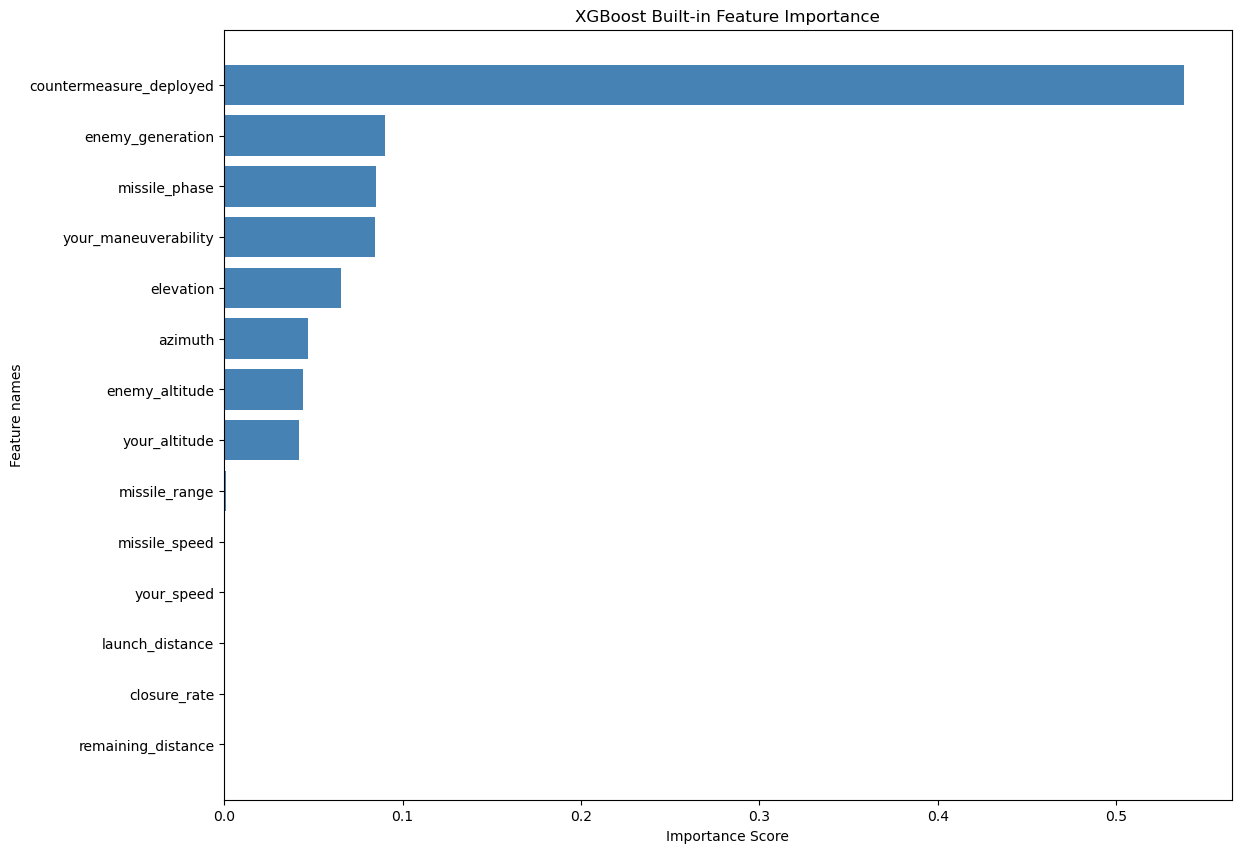

In [74]:
# Plot the Feature importance for the model in horizontal bar graph

# Initialize the figure and axes
fig, ax = plt.subplots(figsize=(13, 10))

# Plot the horizontal bars
# y = features names, width = importance scores
bars = ax.barh(y=sorted_features,
               width=sorted_scores,
               color='steelblue')

# Setting the labels and the title 
ax.set_title("XGBoost Built-in Feature Importance")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature names")

# Inverted y-axis so the highest importace appears at the top
ax.invert_yaxis();

### **Built-in Feature Importance Analysis**

XGBoost's built-in importance uses **gain** (average improvement in loss per split).

#### **Key Findings**

| Rank | Feature | Importance | Group |
|------|---------|------------|-------|
| 1 | `countermeasure_deployed` | ~0.55+ | Countermeasures |
| 2 | `enemy_generation` | ~0.08–0.10 | Threat Specs |
| 3 | `missile_phase` | ~0.08–0.10 | Engagement Geometry |
| 4 | `your_maneuverability` | ~0.08–0.10 | Your Aircraft |
| ... | `remaining_distance`, `closure_rate`, `launch_distance`, `your_speed` | ~0.00 | Geometry / Aircraft |

**`countermeasure_deployed` dominates the model** as single largest predictor by a large margin, consistent with earlier correlation and countplot results showing countermeasures strongly separate hits from misses.

The geometry variables (`remaining_distance`, `closure_rate`, `launch_distance`) that drove ~95% of ETA regressor behavior contribute near-zero importance here. The hit classifier relies on **discrete tactical state** (countermeasures, missile phase, enemy generation, maneuverability) rather than kinematic timing relationships.

#### **Limitation of Built-in Importance**

Built-in XGBoost importance is split/gain-based and **undervalues correlated features**. Highly correlated variables like `missile_speed`, `missile_range`, and geometry features may have their importance routed through a single representative, suppressing the others. SHAP analysis in the next section will correct for this.

---

## **10.2 SHAP Global Summary**

SHAP assigns each feature a value per prediction i.e **how much it shifted the output from the base value**.

**Base value = mean of all model predictions across training data**.

- **Formula:** `base_value + SHAP1 + SHAP2 + ... + SHAP14 = final prediction`

For a classifier, SHAP values operate on the **log-odds scale** i.e positive values push toward hit (1), negative values push toward miss (0).

**Two plots:**
- **Bar plot:** average SHAP magnitude per feature. Better version of built-in importance, mathematically fair to correlated features.
- **Beeswarm plot:** every dot is one row. Shows magnitude, direction, and whether high/low feature values caused the push.

Compare against 10.1 to see where built-in importance agrees with SHAP and where it differs, especially for geometry variables and `missile_speed`/`missile_range` which may be undervalued by gain-based importance.

In [75]:
# CGecking our training data features
X_train.head()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed
0,55165.903660,49340.341120,1434.336528,298.862232,76.854523,0,567.837101,974.992081,2,25845.425760,1372,80000,4.0,0
1,28745.910170,4852.588251,1214.708066,219.398861,0.173912,2,203.550222,25717.200140,1,2583.928379,1372,100000,4.5,1
2,6175.014855,868.337205,929.315766,55.888821,79.677652,2,819.163554,16923.877510,0,3651.367587,847,8000,3.5,0
3,39630.624850,18867.507530,2513.804075,36.204438,-31.212132,1,660.473290,3522.341576,0,6948.906263,2058,100000,4.0,0
4,44895.469460,41715.763780,917.678459,188.340646,-44.462236,0,643.366006,10836.361010,0,25143.619470,1372,160000,5.0,1


In [76]:
len(X_train)

699583

In [77]:
# Import the SHAP library 
from shap import TreeExplainer

# Create a TreeExplainer for the XGBoost classifier
# TreeExplainer is optimized specifically for tree-based models and XGBoost is one of them
explainer = TreeExplainer(model=model)

In [78]:
# # Calculate the SHAP values - one value per feature per row on all the rows of train_df
# shap_values = explainer.shap_values(X_train)

# # Save the SHAP values
# np.save(HIT_DATA_ROOT / "shap_values.npy", shap_values)

In [80]:
# Load the SHAP values 
shap_values = np.load(HIT_DATA_ROOT / "shap_values.npy")
shap_values[0]

array([ 9.3169179e-04,  7.2237891e-03,  4.6998121e-02, -9.5709455e-01,
        4.1707168e+00, -2.3900857e+00, -2.0684322e-02, -3.4528365e+00,
       -4.5095649e+00, -1.7831453e+00,  3.7222295e-03,  2.3028327e-02,
       -1.7256422e+00,  4.4920835e+00], dtype=float32)

In [83]:
# mean of all model predictions across the training data in log-odds units
# basically it's the base values 
base_value = explainer.expected_value
base_value

-0.538356

In [84]:
X_train.values

array([[5.51659037e+04, 4.93403411e+04, 1.43433653e+03, ...,
        8.00000000e+04, 4.00000000e+00, 0.00000000e+00],
       [2.87459102e+04, 4.85258825e+03, 1.21470807e+03, ...,
        1.00000000e+05, 4.50000000e+00, 1.00000000e+00],
       [6.17501486e+03, 8.68337205e+02, 9.29315766e+02, ...,
        8.00000000e+03, 3.50000000e+00, 0.00000000e+00],
       ...,
       [1.48383209e+04, 1.05368962e+04, 9.10055745e+02, ...,
        3.50000000e+04, 4.00000000e+00, 1.00000000e+00],
       [9.29898596e+04, 8.97714240e+04, 1.86500291e+03, ...,
        4.00000000e+05, 5.00000000e+00, 0.00000000e+00],
       [5.39413091e+03, 8.61236113e+02, 7.18393027e+02, ...,
        8.00000000e+03, 4.00000000e+00, 1.00000000e+00]])

In [86]:
# SHAP Explainations object wraps shap_values, raw feature data and feature names
import shap

# base_values is the mean prediction - anchor point for the waterfall plot
# Will be use in plotting graphs
shap_explanations = shap.Explanation(
    values=shap_values,                            # SHAP values calculated by TreeExplainer
    base_values=np.full(len(X_train), base_value), # Mean of all model predictions (base value)
    data=X_train.values,                           # Raw feature values for each row
    feature_names=X_train.columns.to_list()        # Column names for plot labels
)

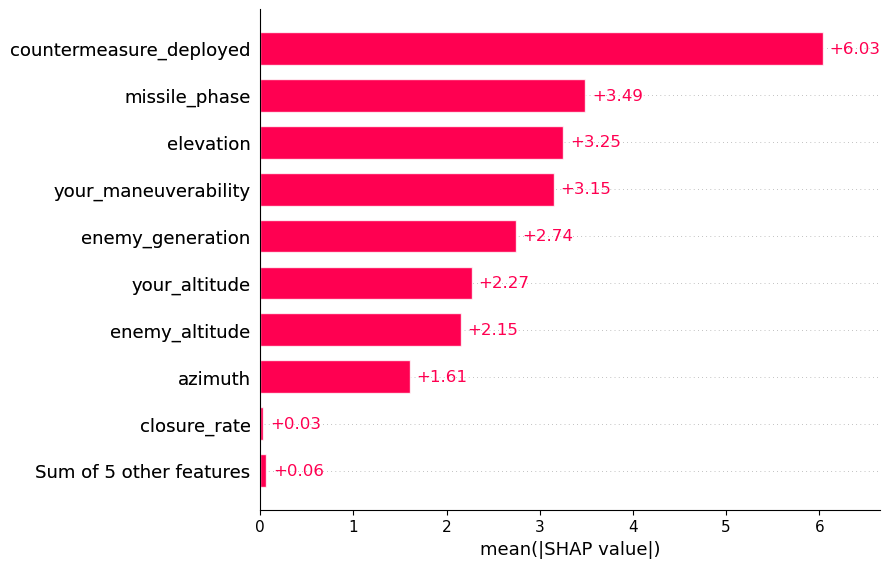

In [87]:
# SHAP Bar Plot
# Average SHAP magnitude per feature across all training rows
# Better version of build-in importance - mathematically fair, no split-frequency bias

shap.plots.bar(shap_explanations)

**X-axis is average SHAP magnitude. Longer bar = more influence on predictions overall. No direction, just "this feature mattered a lot or a little." Read it top to bottom, highest to lowest.**

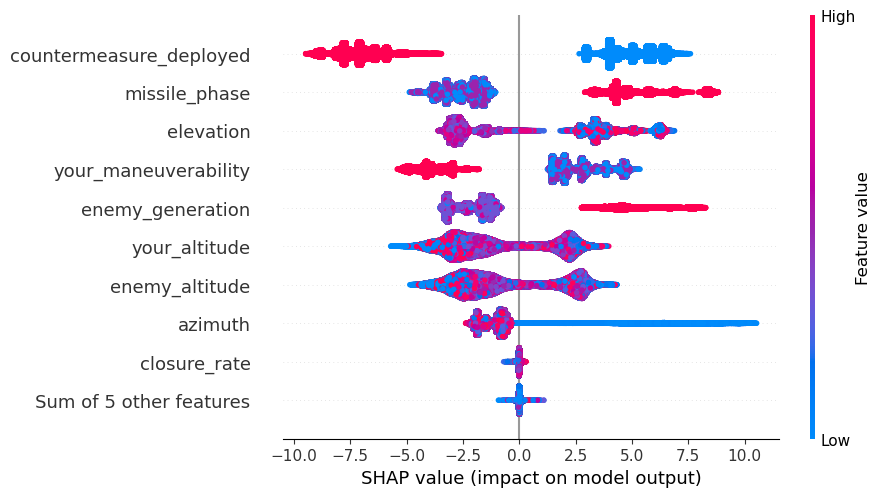

In [88]:
# Shap Beeswarn Plot - every dot is one row from training data
# Shows magnitude, direction, and whether high/low feature values caused the push

shap.plots.beeswarm(shap_explanations)

**Each dot = one row from your dataset.**

**X-axis = SHAP value. Right of zero means that feature pushed evasion_time up (more time, safer). Left of zero means it pushed it down (less time, more dangerous).**

**Color = the actual feature value for that row. Red = high value, blue = low value.**

## **10.2 SHAP Global Summary**

Bar plot confirms `countermeasure_deployed` dominates mean |SHAP| ~6.0, dominates by a large margin over all other features. Geometry variables remain near-zero even under SHAP.

Beeswarm adds direction and per-row detail that built-in importance cannot show.

| Feature | Direction | Physical Reason |
|---------|-----------|-----------------|
| `countermeasure_deployed` | deployed → miss, not deployed → hit | Clean binary gate, almost zero cluster overlap |
| `missile_phase` | high phase → hit | Terminal phase = evasion window has closed |
| `your_maneuverability` | high → miss | More maneuverable aircraft evade more effectively |
| `enemy_generation` | high → hit | Newer aircraft carry more capable missiles |
| `azimuth` | low → hit | Head-on or tail aspect = most dangerous geometry |
| `elevation`, `your_altitude`, `enemy_altitude` | both directions | Interaction-driven, no clean monotonic effect |
| `closure_rate` | near zero | Phase and countermeasures already capture outcome |

**Built-in Importance vs SHAP:**
- Both agree `countermeasure_deployed` dominates and geometry variables are weak.
- SHAP promotes `elevation`, `your_altitude`, and `enemy_altitude` higher than gain importance did as their influence was being suppressed by correlated splits.


**Key finding:** hit classification is driven by tactical state and defensive action, not kinematics. Fundamentally different from the ETA regressor.  